<h1 style='color:#A23B72'>Análisis de Caracterización: 500 Curvas</h1>

<p style='color:#b0b0b0'>Correlacionamos características geométricas de 500 curvas con sus configuraciones gaussianas óptimas. Entrenamos modelos ML para predecir automáticamente la configuración óptima para nuevas curvas.</p>

## 1. Setup

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.signal import find_peaks
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

ROOT = Path.cwd().parent
DATA_T = ROOT / 'datos' / 'target'
RESULTADOS_DIR = ROOT / 'metodo_gaussiano' / 'resultados'

# Cargar resultados completos de 500 curvas
df_ganadores = pd.read_csv(RESULTADOS_DIR / 'completo_configuraciones_ganadoras.csv')

print(f'✓ Datos cargados: {len(df_ganadores)} curvas')

✓ Datos cargados: 500 curvas


## 2. Extraer Características

In [11]:
def leer_target(cid):
    return pd.read_csv(DATA_T / f'curve_{cid:04d}.txt', header=None, names=['x', 'y']).sort_values('x').reset_index(drop=True)

def extraer_caracteristicas(cid):
    """Extrae características geométricas."""
    curva = leer_target(cid)
    x = curva['x'].values.astype(float)
    y = curva['y'].values.astype(float)
    
    y_range = y.max() - y.min()
    x_range = x.max() - x.min()
    
    y_centered = y - y.mean()
    picos, _ = find_peaks(y_centered)
    valles, _ = find_peaks(-y_centered)
    
    dy = np.gradient(y, x)
    d2y = np.gradient(dy, x)
    curvatura = np.abs(d2y) / (1 + dy**2)**1.5
    
    return {
        'curva_id': cid,
        'n_picos': len(picos),
        'n_valles': len(valles),
        'curvatura_media': np.mean(curvatura),
        'curvatura_max': np.max(curvatura),
        'pendiente_media': np.mean(np.abs(dy)),
        'aspect_ratio': y_range / (x_range + 1e-9)
    }

print(f'Extrayendo características de {len(df_ganadores)} curvas...')
caracteristicas_lista = [extraer_caracteristicas(cid) for cid in df_ganadores['curva_id']]
df_caracteristicas = pd.DataFrame(caracteristicas_lista)

print(f'✓ Características extraídas')
print(df_caracteristicas.head())

Extrayendo características de 500 curvas...
✓ Características extraídas
   curva_id  n_picos  n_valles  curvatura_media  curvatura_max  \
0         1        3         2         0.020429       0.065821   
1         2        5         4         0.043195       0.186662   
2         3        3         2         0.022074       0.054327   
3         4        1         1         0.021437       0.082065   
4         5        3         2         0.023466       0.078739   

   pendiente_media  aspect_ratio  
0         0.409474      0.223959  
1         0.643174      0.222725  
2         0.502315      0.308707  
3         0.607108      0.517646  
4         0.534078      0.294700  


## 3. Análisis de Correlaciones

In [12]:
df_analisis = df_caracteristicas.merge(df_ganadores, on='curva_id')

caracteristicas = ['n_picos', 'n_valles', 'curvatura_media', 'curvatura_max', 'pendiente_media', 'aspect_ratio']
correlaciones = {}

for carac in caracteristicas:
    corr, pval = stats.spearmanr(df_analisis[carac], df_analisis['n_campanas'])
    correlaciones[carac] = {'corr': corr, 'pval': pval}

df_corr = pd.DataFrame(correlaciones).T.sort_values('corr', key=abs, ascending=False)
print('CORRELACIONES: Características → n_campanas')
print(df_corr.round(3))

CORRELACIONES: Características → n_campanas
                  corr  pval
aspect_ratio    -0.350   0.0
n_picos          0.342   0.0
n_valles         0.327   0.0
curvatura_max    0.196   0.0
pendiente_media -0.185   0.0
curvatura_media  0.180   0.0


## 4. Árbol de Decisión

In [13]:
X = df_analisis[caracteristicas]
y = df_analisis['n_campanas']

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)

accuracy = tree.score(X, y)
print(f'Precisión Árbol de Decisión: {accuracy:.2%}')
print(f'Número de curvas: {len(X)}')

Precisión Árbol de Decisión: 45.40%
Número de curvas: 500


## 5. Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X, y)

accuracy_rf = rf.score(X, y)
print(f'Precisión Random Forest: {accuracy_rf:.2%}')

importancia = pd.Series(rf.feature_importances_, index=caracteristicas).sort_values(ascending=False)
print(f'\nImportancia de características:')
print(importancia.round(3))

Precisión Random Forest: 57.00%

Importancia de características:
aspect_ratio       0.245
pendiente_media    0.208
curvatura_max      0.192
curvatura_media    0.171
n_picos            0.100
n_valles           0.083
dtype: float64


## 6. Distribución de n_campanas óptimo

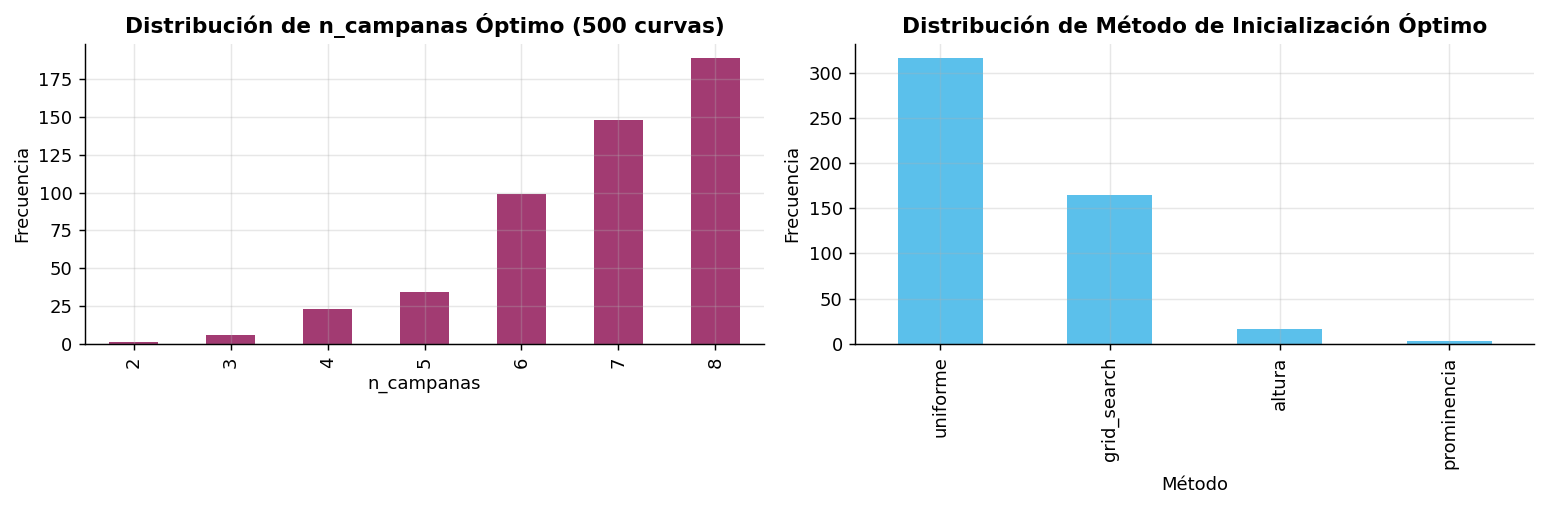


Estadísticas de n_campanas:
count    500.000000
mean       6.848000
std        1.218139
min        2.000000
25%        6.000000
50%        7.000000
75%        8.000000
max        8.000000
Name: n_campanas, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

# Histograma de n_campanas
df_analisis['n_campanas'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#A23B72')
axes[0].set_title('Distribución de n_campanas Óptimo (500 curvas)', fontweight='bold')
axes[0].set_xlabel('n_campanas')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

# Distribución de metodo_init
df_analisis['metodo_init'].value_counts().plot(kind='bar', ax=axes[1], color='#5BC0EB')
axes[1].set_title('Distribución de Método de Inicialización Óptimo', fontweight='bold')
axes[1].set_xlabel('Método')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nEstadísticas de n_campanas:')
print(df_analisis['n_campanas'].describe())

## 7. Resumen y Conclusiones

In [16]:
print(f"✓ Análisis completado con {len(df_analisis)} curvas")
print(f"\nModelos entrenados:")
print(f"  - Árbol de Decisión: {accuracy:.2%} precisión")
print(f"  - Random Forest: {accuracy_rf:.2%} precisión")
print(f"\nCaracterística más predictiva: {df_corr.index[0]} (r={df_corr['corr'].iloc[0]:.3f})")

✓ Análisis completado con 500 curvas

Modelos entrenados:
  - Árbol de Decisión: 45.40% precisión
  - Random Forest: 57.00% precisión

Característica más predictiva: aspect_ratio (r=-0.350)
